In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [223]:
class Linear_Regression_mini_batch:
  def __init__(self,epochs=100,batch_size=1,learning_rate=0.01,shuffle = True):
     self.w, self.b = None,None
     self.epochs = epochs # Số lần học của mô hình
     self.batch_size = batch_size # Số mini_batch lấy ra để huấn luyện
     self.lr = learning_rate # Tham số learning_rate của mô hình
     self.shuffle = True
  # Hàm Dự đoán của mô hình
  def predict(self,X_test):
    return np.dot(X_test,self.w)+self.b

  # Hàm Tính đạo hàm của Loss theo w
  def dL_dw(self,x_train,y_train):
    dL_dw = 2*(self.predict(x_train)-y_train)*x_train
    return dL_dw

  # Hàm Tính đạo hàm của Loss theo b
  def dL_db(self,x_train,y_train):
    return 2*(self.predict(x_train)-y_train)

  # Hàm Loss của mô hình
  def compute_loss(self,y_pred,y):
    return ((y_pred-y)**2).mean()

  # Hàm Huấn Luyện
  def fit(self,X_train,y_train):
    self.data_train = np.append(X_train,y_train.reshape(-1,1),axis=1)
    rd = np.random.uniform(-1,1,size=self.data_train.shape[1])
    self.w, self.b = rd[:-1],rd[-1]
    for epoch in range(self.epochs):
      Losses = []
      if self.shuffle: np.random.shuffle(self.data_train)
      for i in range(0,self.data_train.shape[0],self.batch_size):
        batch = self.data_train[i:i+self.batch_size]
        dL_dw = np.zeros(self.w.shape)
        dL_db = 0
        for sample in batch:
          x, y =sample[:-1],sample[-1]
          dL_dw += self.dL_dw(x,y)
          dL_db += self.dL_db(x,y)
        # Chú ý: do data_train.shape[0]//batch_size !=0 -> tính tb dL_dw và dL_db phải chia cho số lượng sample trong batch lấy được
        self.w = self.w - self.lr*(dL_dw/batch.shape[0])
        self.b = self.b - self.lr*(dL_db/batch.shape[0])
        y_pred = self.predict(batch[:,:-1])
        Losses.append(self.compute_loss(y_pred,batch[:,-1]))
      print(f"epoch: {epoch+1} ======== Loss: {sum(Losses)/len(Losses)} ================= w = {self.w} ============= b ={self.w}")

In [224]:
areas = [6.7, 4.6, 3.5, 5.5]
prices = [9.1, 5.9, 4.6, 6.7]

In [225]:
data = np.array([
    areas,
    prices
]).T
data

array([[6.7, 9.1],
       [4.6, 5.9],
       [3.5, 4.6],
       [5.5, 6.7]])

In [226]:
X_train, y_train = data[:,:-1], data[:,-1]

In [227]:
rg = Linear_Regression_mini_batch(batch_size=2,epochs=300)

In [228]:
rg.fit(X_train,y_train)

epoch: 1 ======== Loss: 2.118416153708436 ================= w = [1.28624995] ============= b =[1.28624995]
epoch: 2 ======== Loss: 0.1420722618779285 ================= w = [1.37053373] ============= b =[1.37053373]
epoch: 3 ======== Loss: 0.04599087647009404 ================= w = [1.37415099] ============= b =[1.37415099]
epoch: 4 ======== Loss: 0.040628533292169894 ================= w = [1.4037651] ============= b =[1.4037651]
epoch: 5 ======== Loss: 0.08063212692189059 ================= w = [1.39630073] ============= b =[1.39630073]
epoch: 6 ======== Loss: 0.042293476217021266 ================= w = [1.40791693] ============= b =[1.40791693]
epoch: 7 ======== Loss: 0.06804269603120433 ================= w = [1.38697836] ============= b =[1.38697836]
epoch: 8 ======== Loss: 0.08098509124061436 ================= w = [1.39374224] ============= b =[1.39374224]
epoch: 9 ======== Loss: 0.041920752059023035 ================= w = [1.40735613] ============= b =[1.40735613]
epoch: 10 ======== Lo

Text(0, 0.5, 'Giá nhà')

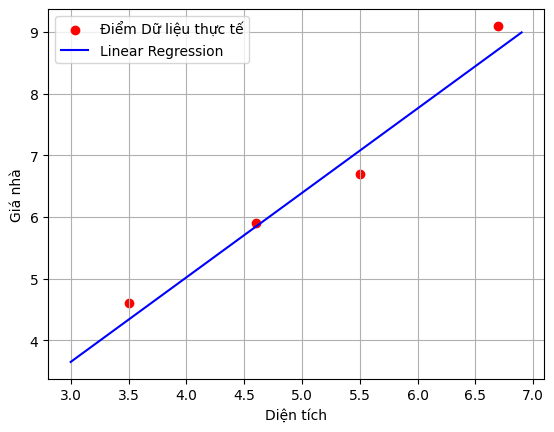

In [230]:
# vẽ mô hình khi đã học xong
plt.scatter(X_train,y_train,color="red",label ='Điểm Dữ liệu thực tế')
# Khởi tạo x, y để vẽ đường thẳng mà mô hình đã học được
x = np.arange(3,7,0.1)
y = rg.w *x +rg.b
plt.plot(x,y,'b',label = 'Linear Regression')
plt.grid()
plt.legend()
plt.xlabel('Diện tích')
plt.ylabel('Giá nhà')